In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install captum

In [ ]:
import random
import math
import sqlite3
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
from captum.attr import IntegratedGradients

In [ ]:
random.seed(255)
np.random.seed(255)
torch.manual_seed(255);

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.LayerNorm(dim)
        )
        self.activation = nn.GELU()

    def forward(self, x):
        return self.activation(x + self.block(x))


class TabularModel(nn.Module):
    def __init__(self, cat_dims, num_numeric, dropout_p=0.2, out_dims=2):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(cat_dim, max(2, min(50, int(1.6 * (cat_dim ** 0.56)))))
            for cat_dim in cat_dims
        ])

        emb_dim = sum(e.embedding_dim for e in self.embeddings)
        input_dim = emb_dim + num_numeric

        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.GELU()
        )

        self.res_blocks = nn.Sequential(
            ResidualBlock(512, dropout_p),
            ResidualBlock(512, dropout_p),
            ResidualBlock(512, dropout_p)
        )

        self.head = nn.Sequential(
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout_p),

            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU()
        )

        self.out = nn.Linear(128, out_dims)

    def forward(self, x_cat, x_num):
        emb = [emb_layer(x_cat[:, i]) for i, emb_layer in enumerate(self.embeddings)]
        emb = torch.cat(emb, dim=1)

        x = torch.cat([emb, x_num], dim=1)

        x = self.input_layer(x)
        x = self.res_blocks(x)
        x = self.head(x)

        return self.out(x)

In [ ]:
db = sqlite3.connect("/content/drive/MyDrive/Datasets/Cleaned/dat490.db")

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", db)
print(tables)
print(pd.read_sql("SELECT * FROM poverty_estimates;", db).columns)
df_combined = pd.read_sql("""
    SELECT *
    FROM public_schools ps
    LEFT JOIN poverty_estimates pe
      ON ps.school_id = pe.school_id
    LEFT JOIN math m
      ON ps.school_id = m.school_id
    LEFT JOIN reading_language_arts rla
      ON ps.school_id = rla.school_id
    LEFT JOIN graduation_rates gr
      ON ps.school_id = gr.school_id
""", db)

df_combined = df_combined.loc[:, ~df_combined.columns.duplicated()]

for i, item in enumerate(df_combined.columns):
  print(item, end = ',')
  if i % 10 == 0 and i != 0:
    print()

                    name
0         public_schools
1      poverty_estimates
2                   math
3  reading_language_arts
4       graduation_rates
Index(['school_id', 'school_name', 'income_to_poverty_ratio_estimate',
       'income_to_poverty_ratio_standard_error'],
      dtype='object')
x,y,object_id,school_id,servey_year,state,district_id,local_education_agency,school_name,street_1,street_2,
city,zip,zip4,phone,charter,magnet,virtual,lowest_grade_level,highest_grade_level,school_level,
title_one,status,school_type,operational,local_type,conty_name,total_free_reduced_lunch,free_lunch,reduced_lunch,prek_students,
kindergarden_students,first_students,second_students,third_students,fourth_students,fith_students,sixth_students,seventh_students,eighth_students,nineth_students,
tenth_students,eleventh_students,twelth_students,thirteenth_students,ungraded_students,alternative_education,total_male_students,total_female_students,total_students,facualty_fulltime_equivilant,
student_teacher_

In [ ]:
df_public = df_combined[[col for col in df_combined.columns if col in [
    'school_id', 'total_students', 'student_teacher_ratio',
    'facualty_fulltime_equivilant'
]]]

df_poverty = df_combined[['school_id', 'income_to_poverty_ratio_estimate',
                 'income_to_poverty_ratio_standard_error']]

df_math = df_combined[[col for col in df_combined.columns if 'math' in col]]

df_rla = df_combined[[col for col in df_combined.columns if 'rla' in col]]

df_grad = df_combined[[col for col in df_combined.columns if 'grad' in col]]

In [ ]:
# df_total = pd.read_sql("""
#   SELECT
#     ps.state,
#     ps.virtual,
#     ps.title_one,
#     ps.free_lunch,
#     ps.reduced_lunch,
#     ps.total_students,
#     ps.total_male_students,
#     ps.total_female_students,
#     ps.facualty_fulltime_equivilant,
#     ps.student_teacher_ratio,

#     ps.american_indian_alaska_native_total,
#     ps.asian_total,
#     ps.black_total,
#     ps.hispanic_total,
#     ps.native_hawaiian_pacific_islander_total,
#     ps.two_or_more_race_total,
#     ps.white_total,

#     pe.income_to_poverty_ratio_estimate,

#     m.total_proficiency_math,
#     m.all_categories_students_math,
#     m.dissability_students_math,
#     m.economically_disadvantaged_students_math,
#     m.female_students_math,
#     m.foster_students_math,
#     m.homeless_students_math,
#     m.english_learner_students_math,
#     m.male_students_math,
#     m.military_connected_students_math,

#     rla.total_proficiency_rla,
#     rla.all_categories_students_rla,
#     rla.dissability_students_rla,
#     rla.economically_disadvantaged_students_rla,
#     rla.female_students_rla,
#     rla.foster_students_rla,
#     rla.homeless_students_rla,
#     rla.english_learner_students_rla,
#     rla.male_students_rla,
#     rla.military_connected_students_rla

#     FROM public_schools ps
#     LEFT JOIN poverty_estimates pe
#         ON ps.school_id = pe.school_id
#     LEFT JOIN math m
#         ON ps.school_id = m.school_id
#     LEFT JOIN reading_language_arts rla
#         ON ps.school_id = rla.school_id
#     WHERE
#         ps.status = 1
#         AND ps.total_students > 100
# """, db)

In [ ]:
df_total = pd.read_sql("""
    SELECT
        ps.state,
        ps.virtual,
        ps.title_one,
        ps.free_lunch,
        ps.reduced_lunch,
        ps.total_students,
        ps.total_male_students,
        ps.total_female_students,
        ps.facualty_fulltime_equivilant,
        ps.student_teacher_ratio,

        ps.american_indian_alaska_native_total,
        ps.asian_total,
        ps.black_total,
        ps.hispanic_total,
        ps.native_hawaiian_pacific_islander_total,
        ps.two_or_more_race_total,
        ps.white_total,

        pe.income_to_poverty_ratio_estimate,

        m.all_categories_students_math,
        m.dissability_students_math,
        m.economically_disadvantaged_students_math,
        m.female_students_math,
        m.foster_students_math,
        m.homeless_students_math,
        m.english_learner_students_math,
        m.male_students_math,
        m.military_connected_students_math,

        rla.all_categories_students_rla,
        rla.dissability_students_rla,
        rla.economically_disadvantaged_students_rla,
        rla.female_students_rla,
        rla.foster_students_rla,
        rla.homeless_students_rla,
        rla.english_learner_students_rla,
        rla.male_students_rla,
        rla.military_connected_students_rla,

        g.all_categories_students_grad,
        g.dissability_rate_grad,
        g.economically_disadvantaged_students_grad,
        g.foster_rate_grad,
        g.homeless_rate_grad,
        g.english_learner_students_grad,
        g.american_indian_alaska_native_rate_grad,
        g.asian_pacific_islander_rate_grad,
        g.black_rate_grad,
        g.hispanic_rate_grad,
        g.two_or_more_race_rate_grad,
        g.white_rate_grad

    FROM public_schools ps
    LEFT JOIN poverty_estimates pe
        ON ps.school_id = pe.school_id
    LEFT JOIN math m
        ON ps.school_id = m.school_id
    LEFT JOIN reading_language_arts rla
        ON ps.school_id = rla.school_id
    LEFT JOIN graduation_rates g
        ON ps.school_id = g.school_id
    WHERE ps.status = 1
        AND ps.total_students > 100
        AND g.all_categories_rate_grad IS NOT NULL
        AND g.all_categories_rate_grad IS NOT 0
""", db)

In [ ]:
class TabularDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, num_cat_cols):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.num_cat_cols = num_cat_cols

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.y[idx]

        x_cat = x[:self.num_cat_cols].long()
        x_num = x[self.num_cat_cols:].float()

        return x_cat, x_num, y

In [ ]:
print(df_total.columns)

Index(['state', 'virtual', 'title_one', 'free_lunch', 'reduced_lunch',
       'total_students', 'total_male_students', 'total_female_students',
       'facualty_fulltime_equivilant', 'student_teacher_ratio',
       'american_indian_alaska_native_total', 'asian_total', 'black_total',
       'hispanic_total', 'native_hawaiian_pacific_islander_total',
       'two_or_more_race_total', 'white_total',
       'income_to_poverty_ratio_estimate', 'all_categories_students_math',
       'dissability_students_math', 'economically_disadvantaged_students_math',
       'female_students_math', 'foster_students_math',
       'homeless_students_math', 'english_learner_students_math',
       'male_students_math', 'military_connected_students_math',
       'all_categories_students_rla', 'dissability_students_rla',
       'economically_disadvantaged_students_rla', 'female_students_rla',
       'foster_students_rla', 'homeless_students_rla',
       'english_learner_students_rla', 'male_students_rla',
      

In [ ]:
# # math / rla
# cat_cols = ["state", "virtual"]

# raw_num_cols = [
#     "title_one",
#     "free_lunch",
#     "reduced_lunch",
#     "total_students",
#     "total_male_students",
#     "total_female_students",
#     "facualty_fulltime_equivilant",
#     "student_teacher_ratio",
#     "income_to_poverty_ratio_estimate",
#     "all_categories_students_math",
#     "all_categories_students_rla"
# ]

# df_total[raw_num_cols] = df_total[raw_num_cols].replace([np.inf, -np.inf], np.nan)
# df_total[raw_num_cols] = df_total[raw_num_cols].fillna(0)

# total_students_safe = df_total["total_students"].replace(0, np.nan)

# math_den = df_total["all_categories_students_math"].replace(0, np.nan)
# rla_den  = df_total["all_categories_students_rla"].replace(0, np.nan)

# df_total["free_lunch_ratio"] = df_total["free_lunch"] / total_students_safe
# df_total["reduced_lunch_ratio"] = df_total["reduced_lunch"] / total_students_safe

# df_total["male_ratio"] = df_total["total_male_students"] / total_students_safe
# df_total["female_ratio"] = df_total["total_female_students"] / total_students_safe

# df_total[[
#     "free_lunch_ratio",
#     "reduced_lunch_ratio",
#     "male_ratio",
#     "female_ratio"
# ]] = df_total[[
#     "free_lunch_ratio",
#     "reduced_lunch_ratio",
#     "male_ratio",
#     "female_ratio"
# ]].fillna(0)

# math_ratio_cols = [
#     "dissability_students_math",
#     "economically_disadvantaged_students_math",
#     "female_students_math",
#     "foster_students_math",
#     "homeless_students_math",
#     "english_learner_students_math",
#     "male_students_math",
#     "military_connected_students_math"
# ]

# for col in math_ratio_cols:
#     df_total[f"{col}_ratio"] = df_total[col] / math_den

# df_total[[f"{col}_ratio" for col in math_ratio_cols]] = \
#     df_total[[f"{col}_ratio" for col in math_ratio_cols]].fillna(0)

# rla_ratio_cols = [
#     "dissability_students_rla",
#     "economically_disadvantaged_students_rla",
#     "female_students_rla",
#     "foster_students_rla",
#     "homeless_students_rla",
#     "english_learner_students_rla",
#     "male_students_rla",
#     "military_connected_students_rla"
# ]

# for col in rla_ratio_cols:
#     df_total[f"{col}_ratio"] = df_total[col] / rla_den

# df_total[[f"{col}_ratio" for col in rla_ratio_cols]] = \
#     df_total[[f"{col}_ratio" for col in rla_ratio_cols]].fillna(0)

# df_total["poverty_x_lunch"] = (
#     df_total["income_to_poverty_ratio_estimate"] * df_total["free_lunch_ratio"]
# )

# df_total["poverty_x_student_teacher"] = (
#     df_total["income_to_poverty_ratio_estimate"] * df_total["student_teacher_ratio"]
# )

# df_total["size_x_poverty"] = (
#     df_total["total_students"] * df_total["income_to_poverty_ratio_estimate"]
# )

# feature_cols = cat_cols + [
#     "total_students",
#     "student_teacher_ratio",
#     "income_to_poverty_ratio_estimate",
#     "all_categories_students_math",
#     "all_categories_students_rla",

#     "free_lunch_ratio",
#     "reduced_lunch_ratio",
#     "male_ratio",
#     "female_ratio",

#     "poverty_x_lunch",
#     "poverty_x_student_teacher",
#     "size_x_poverty"
# ]

# feature_cols += [f"{col}_ratio" for col in math_ratio_cols]
# feature_cols += [f"{col}_ratio" for col in rla_ratio_cols]

# encoders = {}
# for col in cat_cols:
#     le = LabelEncoder()

#     df_total[col] = df_total[col].astype(str)

#     le.fit(df_total[col])
#     df_total[col] = le.transform(df_total[col])

#     encoders[col] = le

# cat_dims = [df_total[col].nunique() for col in cat_cols]

# target_cols = ["total_proficiency_rla", "total_proficiency_math"]

# df_total = df_total.replace([np.inf, -np.inf], np.nan)

# df_total = df_total.dropna(subset=feature_cols + target_cols).reset_index(drop=True)

# X = df_total[feature_cols]
# y = df_total[target_cols]

# X_values = X.values
# y_values = y.values

In [ ]:
cat_cols = ["state", "virtual"]

raw_num_cols = [
    "title_one",
    "free_lunch",
    "reduced_lunch",
    "total_students",
    "total_male_students",
    "total_female_students",
    "facualty_fulltime_equivilant",
    "student_teacher_ratio",
    "american_indian_alaska_native_total",
    "asian_total",
    "black_total",
    "hispanic_total",
    "native_hawaiian_pacific_islander_total",
    "two_or_more_race_total",
    "white_total",
    "income_to_poverty_ratio_estimate",
    "all_categories_students_math",
    "dissability_students_math",
    "economically_disadvantaged_students_math",
    "female_students_math",
    "foster_students_math",
    "homeless_students_math",
    "english_learner_students_math",
    "male_students_math",
    "military_connected_students_math",
    "all_categories_students_rla",
    "dissability_students_rla",
    "economically_disadvantaged_students_rla",
    "female_students_rla",
    "foster_students_rla",
    "homeless_students_rla",
    "english_learner_students_rla",
    "male_students_rla",
    "military_connected_students_rla"
]

raw_num_cols = [col for col in raw_num_cols if col in df_total.columns]

rate_cols = [
    "total_proficiency_rla",
    "total_proficiency_math"
]

rate_cols = [col for col in rate_cols if col in df_total.columns]

for col in rate_cols:
    df_total[col] = (
        df_total[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .replace("nan", np.nan)
    )
    df_total[col] = pd.to_numeric(df_total[col], errors="coerce")

df_total[raw_num_cols] = df_total[raw_num_cols].replace([np.inf, -np.inf], np.nan)
df_total[raw_num_cols] = df_total[raw_num_cols].fillna(0)

total_students_safe = df_total["total_students"].replace(0, np.nan)

math_den = df_total["all_categories_students_math"].replace(0, np.nan)
rla_den = df_total["all_categories_students_rla"].replace(0, np.nan)

df_total["free_lunch_ratio"] = df_total["free_lunch"] / total_students_safe
df_total["reduced_lunch_ratio"] = df_total["reduced_lunch"] / total_students_safe
df_total["male_ratio"] = df_total["total_male_students"] / total_students_safe
df_total["female_ratio"] = df_total["total_female_students"] / total_students_safe

df_total[[
    "free_lunch_ratio",
    "reduced_lunch_ratio",
    "male_ratio",
    "female_ratio"
]] = df_total[[
    "free_lunch_ratio",
    "reduced_lunch_ratio",
    "male_ratio",
    "female_ratio"
]].fillna(0)

math_ratio_cols = [
    "dissability_students_math",
    "economically_disadvantaged_students_math",
    "female_students_math",
    "foster_students_math",
    "homeless_students_math",
    "english_learner_students_math",
    "male_students_math",
    "military_connected_students_math"
]

math_ratio_cols = [col for col in math_ratio_cols if col in df_total.columns]

for col in math_ratio_cols:
    df_total[f"{col}_ratio"] = df_total[col] / math_den

df_total[[f"{col}_ratio" for col in math_ratio_cols]] = \
    df_total[[f"{col}_ratio" for col in math_ratio_cols]].fillna(0)

rla_ratio_cols = [
    "dissability_students_rla",
    "economically_disadvantaged_students_rla",
    "female_students_rla",
    "foster_students_rla",
    "homeless_students_rla",
    "english_learner_students_rla",
    "male_students_rla",
    "military_connected_students_rla"
]

rla_ratio_cols = [col for col in rla_ratio_cols if col in df_total.columns]

for col in rla_ratio_cols:
    df_total[f"{col}_ratio"] = df_total[col] / rla_den

df_total[[f"{col}_ratio" for col in rla_ratio_cols]] = \
    df_total[[f"{col}_ratio" for col in rla_ratio_cols]].fillna(0)

df_total["poverty_x_lunch"] = (
    df_total["income_to_poverty_ratio_estimate"] * df_total["free_lunch_ratio"]
)

df_total["poverty_x_student_teacher"] = (
    df_total["income_to_poverty_ratio_estimate"] * df_total["student_teacher_ratio"]
)

df_total["size_x_poverty"] = (
    df_total["total_students"] * df_total["income_to_poverty_ratio_estimate"]
)

feature_cols = cat_cols + [
    "total_students",
    "total_male_students",
    "total_female_students",
    "facualty_fulltime_equivilant",
    "student_teacher_ratio",
    "income_to_poverty_ratio_estimate",
    "all_categories_students_math",
    "all_categories_students_rla",
    "free_lunch_ratio",
    "reduced_lunch_ratio",
    "male_ratio",
    "female_ratio",
    "poverty_x_lunch",
    "poverty_x_student_teacher",
    "size_x_poverty"
]

feature_cols += [
    col for col in [
        "american_indian_alaska_native_total",
        "asian_total",
        "black_total",
        "hispanic_total",
        "native_hawaiian_pacific_islander_total",
        "two_or_more_race_total",
        "white_total"
    ] if col in df_total.columns
]

feature_cols += [f"{col}_ratio" for col in math_ratio_cols]
feature_cols += [f"{col}_ratio" for col in rla_ratio_cols]

encoders = {}
for col in cat_cols:
    if col in df_total.columns:
        le = LabelEncoder()
        df_total[col] = le.fit_transform(df_total[col].astype(str))
        encoders[col] = le

cat_dims = [df_total[col].nunique() for col in cat_cols if col in df_total.columns]

target_cols = ["all_categories_students_grad"]
target_cols = [col for col in target_cols if col in df_total.columns]

df_total = df_total.replace([np.inf, -np.inf], np.nan)
df_total = df_total.dropna(subset=feature_cols + target_cols).reset_index(drop=True)

X = df_total[feature_cols]
y = df_total[target_cols]

X_values = X.values
y_values = y.values

In [ ]:
print(np.isnan(X_values).any())
print(np.isnan(y_values).any())
print(len(X_values))
print(len(y_values))

False
False
11950
11950


In [ ]:
# # math / rla
# X = df_total[feature_cols]
# y = df_total[target_cols]

# X = X.replace([np.inf, -np.inf], np.nan)
# y = y.replace([np.inf, -np.inf], np.nan)

# mask = ~(X.isna().any(axis=1) | y.isna().any(axis=1))
# X = X[mask]
# y = y[mask]

# X_values = X.values
# y_values = y.values

# X_train, X_temp, y_train, y_temp = train_test_split(
#     X_values, y_values, test_size=0.2, random_state=42
# )

# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp, y_temp, test_size=0.5, random_state=42
# )

# num_cat_cols = len(cat_cols)

# def split_cat_num(X):
#     X_cat = X[:, :num_cat_cols]
#     X_num = X[:, num_cat_cols:]
#     return X_cat, X_num

# X_train_cat, X_train_num = split_cat_num(X_train)
# X_val_cat, X_val_num     = split_cat_num(X_val)
# X_test_cat, X_test_num   = split_cat_num(X_test)

# def log_transform(X):
#     return np.sign(X) * np.log1p(np.abs(X))

# X_train_num = log_transform(X_train_num)
# X_val_num   = log_transform(X_val_num)
# X_test_num  = log_transform(X_test_num)

# scaler = RobustScaler()

# X_train_num = scaler.fit_transform(X_train_num)
# X_val_num   = scaler.transform(X_val_num)
# X_test_num  = scaler.transform(X_test_num)

# X_train_cat = torch.tensor(X_train_cat).long()
# X_val_cat   = torch.tensor(X_val_cat).long()
# X_test_cat  = torch.tensor(X_test_cat).long()

# X_train_num = torch.tensor(X_train_num).float()
# X_val_num   = torch.tensor(X_val_num).float()
# X_test_num  = torch.tensor(X_test_num).float()

# y_train = torch.tensor(y_train).float()
# y_val   = torch.tensor(y_val).float()
# y_test  = torch.tensor(y_test).float()

# y_mean = y_train.mean(dim=0)
# y_std  = y_train.std(dim=0) + 1e-8

# y_train = (y_train - y_mean) / y_std
# y_val   = (y_val - y_mean) / y_std
# y_test  = (y_test - y_mean) / y_std

# train_dataset = TensorDataset(X_train_cat, X_train_num, y_train)
# val_dataset   = TensorDataset(X_val_cat, X_val_num, y_val)
# test_dataset  = TensorDataset(X_test_cat, X_test_num, y_test)

# batch_size = 64

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
# test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# Grad rate
target_col = target_cols[0]

X = df_total[feature_cols].values
y = df_total[target_col].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

cat_idx = [feature_cols.index(c) for c in cat_cols]
num_idx = [i for i in range(len(feature_cols)) if i not in cat_idx]

X_train_cat = torch.tensor(X_train[:, cat_idx]).long()
X_val_cat   = torch.tensor(X_val[:, cat_idx]).long()
X_test_cat  = torch.tensor(X_test[:, cat_idx]).long()

X_train_num = X_train[:, num_idx]
X_val_num   = X_val[:, num_idx]
X_test_num  = X_test[:, num_idx]

scaler = RobustScaler()

X_train_num = scaler.fit_transform(X_train_num)
X_val_num   = scaler.transform(X_val_num)
X_test_num  = scaler.transform(X_test_num)

X_train_num = torch.tensor(X_train_num).float()
X_val_num   = torch.tensor(X_val_num).float()
X_test_num  = torch.tensor(X_test_num).float()

y_train = torch.tensor(y_train).float().unsqueeze(1)
y_val   = torch.tensor(y_val).float().unsqueeze(1)
y_test  = torch.tensor(y_test).float().unsqueeze(1)

y_mean = y_train.mean(dim=0)
y_std  = y_train.std(dim=0, unbiased=False)

y_std = torch.where(y_std < 1e-6, torch.ones_like(y_std), y_std)

y_train = (y_train - y_mean) / y_std
y_val   = (y_val - y_mean) / y_std
y_test  = (y_test - y_mean) / y_std

y_train = y_train.view(-1)
y_val   = y_val.view(-1)
y_test  = y_test.view(-1)

train_dataset = TensorDataset(X_train_cat, X_train_num, y_train)
val_dataset   = TensorDataset(X_val_cat, X_val_num, y_val)
test_dataset  = TensorDataset(X_test_cat, X_test_num, y_test)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Final shapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("Numeric:", X_train_num.shape)
print("Categorical:", X_train_cat.shape)

print("y_train:", y_train.shape)

X shape: (11950, 40)
y shape: (11950,)
Final shapes:
X_train: (9560, 40)
X_val: (1195, 40)
X_test: (1195, 40)
Numeric: torch.Size([9560, 38])
Categorical: torch.Size([9560, 2])
y_train: torch.Size([9560])


In [ ]:
print(y_train.shape)

torch.Size([9560])


In [ ]:
def weighted_huber_loss(preds, targets):
    base_loss = F.smooth_l1_loss(preds, targets, reduction='none')
    weights = torch.abs(targets - targets.mean(dim=0))
    return (weights * base_loss).mean()

In [ ]:
# # math / rla
# num_numeric = len(feature_cols) - len(cat_cols)
# model = TabularModel(cat_dims, num_numeric, out_dims=2)

# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
# # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
# criterion = nn.HuberLoss(delta=1.0)

# train_losses, val_losses, val_r2 = [], [], []
# val_rmse_list, val_mae_list = [], []

# r2_history = []
# val_loss_history = []

# gap_history = []
# rel_gap_history = []
# combined_gap_history = []

# # num_epochs = 1000
# warmup_epochs = 50

# r2_window = 5
# r2_eps = 1e-5

# val_window = 5
# val_loss_eps = 1e-4

# max_combined_gap = 0.25

# ema_alpha = 0.2
# gap_patience = 5
# early_stop_patience = 25
# cooldown_epochs = 3

# ema_gap = None
# ema_rel_gap = None

# overfit_counter = 0
# cooldown_counter = 0

# best_val_loss = float('inf')
# best_epoch = 0
# epoch = 0


# while True:
#     model.train()
#     train_loss = 0

#     for x_cat, x_num, y in train_loader:
#         optimizer.zero_grad()

#         preds = model(x_cat, x_num).squeeze()
#         loss = criterion(preds, y)

#         loss.backward()
#         optimizer.step()

#         train_loss += loss.item()

#     train_loss /= len(train_loader)

#     model.eval()
#     val_loss = 0
#     preds_all = []
#     y_all = []

#     with torch.no_grad():
#         for x_cat, x_num, y in val_loader:
#             preds = model(x_cat, x_num).squeeze()
#             loss = criterion(preds, y)

#             val_loss += loss.item()
#             preds_all.append(preds)
#             y_all.append(y)

#     val_loss /= len(val_loader)

#     preds_all = torch.cat(preds_all)
#     y_all = torch.cat(y_all)

#     r2 = r2_score(y_all.numpy(), preds_all.numpy())
#     rmse = torch.sqrt(torch.mean((preds_all - y_all) ** 2)).item()
#     mae = torch.mean(torch.abs(preds_all - y_all)).item()

#     train_losses.append(train_loss)
#     val_losses.append(val_loss)
#     val_r2.append(r2)
#     val_rmse_list.append(rmse)
#     val_mae_list.append(mae)

#     gap = abs(val_loss - train_loss)
#     rel_gap = gap / (val_loss + 1e-8)

#     gap_history.append(gap)
#     rel_gap_history.append(rel_gap)

#     if ema_gap is None:
#         ema_gap = gap
#         ema_rel_gap = rel_gap
#     else:
#         ema_gap = ema_alpha * gap + (1 - ema_alpha) * ema_gap
#         ema_rel_gap = ema_alpha * rel_gap + (1 - ema_alpha) * ema_rel_gap

#     combined_gap = combined_gap = ema_rel_gap
#     combined_gap_history.append(combined_gap)

#     if val_loss < best_val_loss - 1e-4:
#         best_val_loss = val_loss
#         best_epoch = epoch
#         overfit_counter = 0
#         cooldown_counter = cooldown_epochs

#         torch.save({
#             "model_state_dict": model.state_dict(),
#             "optimizer_state_dict": optimizer.state_dict(),
#             "epoch": epoch,
#             "val_loss": val_loss
#         }, "best_model.pth")
#     else:
#         overfit_counter += 1

#     scheduler.step(val_loss)

#     if cooldown_counter > 0:
#         cooldown_counter -= 1

#     r2_history.append(r2)
#     if len(r2_history) > r2_window:
#         r2_history.pop(0)

#     val_loss_history.append(val_loss)
#     if len(val_loss_history) > val_window:
#         val_loss_history.pop(0)

#     if epoch >= warmup_epochs:

#         if len(r2_history) == r2_window:
#             r2_improvement = r2_history[-1] - r2_history[0]
#             r2_flat = abs(r2_improvement) < r2_eps
#         else:
#             r2_flat = False

#         if len(val_loss_history) == val_window:
#             val_loss_improvement = val_loss_history[-1] - val_loss_history[0]
#             val_loss_flat = abs(val_loss_improvement) < val_loss_eps
#         else:
#             val_loss_flat = False

#         if combined_gap > max_combined_gap and cooldown_counter == 0:
#             if len(combined_gap_history) >= gap_patience:
#                 recent = combined_gap_history[-gap_patience:]
#                 if all(g > max_combined_gap for g in recent):
#                     print(f"Early stopping at epoch {epoch+1}: sustained overfitting")
#                     break

#         if r2_flat and val_loss_flat:
#             print(f"Early stopping at epoch {epoch+1}: convergence")
#             break

#         if epoch - best_epoch > early_stop_patience:
#             print(f"Early stopping at epoch {epoch+1}: no val improvement")
#             break

#     print(
#         f"Epoch {epoch+1}: "
#         f"Train={train_loss:.4f}, "
#         f"Val={val_loss:.4f}, "
#         f"Gap={gap:.4f}, "
#         f"EMA_Gap={ema_gap:.4f}, "
#         f"Combined={combined_gap:.4f}, "
#         f"R2={r2:.6f}"
#     )
#     epoch += 1

In [ ]:
num_numeric = len(feature_cols) - len(cat_cols)
model = TabularModel(cat_dims, num_numeric, out_dims=1)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
criterion = nn.HuberLoss(delta=1.0)

train_losses, val_losses, val_r2 = [], [], []
val_rmse_list, val_mae_list = [], []

r2_history = []
val_loss_history = []

gap_history = []
rel_gap_history = []
combined_gap_history = []

# num_epochs = 1000
warmup_epochs = 50

r2_window = 5
r2_eps = 1e-5

val_window = 5
val_loss_eps = 1e-4

max_combined_gap = 0.25

ema_alpha = 0.2
gap_patience = 5
early_stop_patience = 25
cooldown_epochs = 3

ema_gap = None
ema_rel_gap = None

overfit_counter = 0
cooldown_counter = 0

best_val_loss = float('inf')
best_epoch = 0
epoch = 0


while True:
    model.train()
    train_loss = 0

    for x_cat, x_num, y in train_loader:
        optimizer.zero_grad()

        preds = model(x_cat, x_num).squeeze()
        loss = criterion(preds, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    preds_all = []
    y_all = []

    with torch.no_grad():
        for x_cat, x_num, y in val_loader:
            preds = model(x_cat, x_num).squeeze()
            loss = criterion(preds, y)

            val_loss += loss.item()
            preds_all.append(preds)
            y_all.append(y)

    val_loss /= len(val_loader)

    preds_all = torch.cat(preds_all)
    y_all = torch.cat(y_all)

    r2 = r2_score(y_all.numpy(), preds_all.numpy())
    rmse = torch.sqrt(torch.mean((preds_all - y_all) ** 2)).item()
    mae = torch.mean(torch.abs(preds_all - y_all)).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_r2.append(r2)
    val_rmse_list.append(rmse)
    val_mae_list.append(mae)

    gap = abs(val_loss - train_loss)
    rel_gap = gap / (val_loss + 1e-8)

    gap_history.append(gap)
    rel_gap_history.append(rel_gap)

    if ema_gap is None:
        ema_gap = gap
        ema_rel_gap = rel_gap
    else:
        ema_gap = ema_alpha * gap + (1 - ema_alpha) * ema_gap
        ema_rel_gap = ema_alpha * rel_gap + (1 - ema_alpha) * ema_rel_gap

    combined_gap = combined_gap = ema_rel_gap
    combined_gap_history.append(combined_gap)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_epoch = epoch
        overfit_counter = 0
        cooldown_counter = cooldown_epochs

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "val_loss": val_loss
        }, "best_model.pth")
    else:
        overfit_counter += 1

    scheduler.step(val_loss)

    if cooldown_counter > 0:
        cooldown_counter -= 1

    r2_history.append(r2)
    if len(r2_history) > r2_window:
        r2_history.pop(0)

    val_loss_history.append(val_loss)
    if len(val_loss_history) > val_window:
        val_loss_history.pop(0)

    if epoch >= warmup_epochs:

        if len(r2_history) == r2_window:
            r2_improvement = r2_history[-1] - r2_history[0]
            r2_flat = abs(r2_improvement) < r2_eps
        else:
            r2_flat = False

        if len(val_loss_history) == val_window:
            val_loss_improvement = val_loss_history[-1] - val_loss_history[0]
            val_loss_flat = abs(val_loss_improvement) < val_loss_eps
        else:
            val_loss_flat = False

        if combined_gap > max_combined_gap and cooldown_counter == 0:
            if len(combined_gap_history) >= gap_patience:
                recent = combined_gap_history[-gap_patience:]
                if all(g > max_combined_gap for g in recent):
                    print(f"Early stopping at epoch {epoch+1}: sustained overfitting")
                    break

        if r2_flat and val_loss_flat:
            print(f"Early stopping at epoch {epoch+1}: convergence")
            break

        if epoch - best_epoch > early_stop_patience:
            print(f"Early stopping at epoch {epoch+1}: no val improvement")
            break

    print(
        f"Epoch {epoch+1}: "
        f"Train={train_loss:.4f}, "
        f"Val={val_loss:.4f}, "
        f"Gap={gap:.4f}, "
        f"EMA_Gap={ema_gap:.4f}, "
        f"Combined={combined_gap:.4f}, "
        f"R2={r2:.6f}"
    )
    epoch += 1

Epoch 1: Train=0.1757, Val=0.0953, Gap=0.0804, EMA_Gap=0.0804, Combined=0.8435, R2=0.679348
Epoch 2: Train=0.1174, Val=0.1083, Gap=0.0091, EMA_Gap=0.0661, Combined=0.6916, R2=0.633960
Epoch 3: Train=0.1015, Val=0.0677, Gap=0.0338, EMA_Gap=0.0596, Combined=0.6530, R2=0.799361
Epoch 4: Train=0.0888, Val=0.0733, Gap=0.0155, EMA_Gap=0.0508, Combined=0.5648, R2=0.779532
Epoch 5: Train=0.0810, Val=0.0619, Gap=0.0192, EMA_Gap=0.0445, Combined=0.5137, R2=0.819084
Epoch 6: Train=0.0689, Val=0.0698, Gap=0.0009, EMA_Gap=0.0358, Combined=0.4137, R2=0.797004
Epoch 7: Train=0.0686, Val=0.0629, Gap=0.0057, EMA_Gap=0.0298, Combined=0.3490, R2=0.813181
Epoch 8: Train=0.0643, Val=0.0584, Gap=0.0059, EMA_Gap=0.0250, Combined=0.2993, R2=0.828025
Epoch 9: Train=0.0567, Val=0.0565, Gap=0.0002, EMA_Gap=0.0200, Combined=0.2402, R2=0.835194
Epoch 10: Train=0.0542, Val=0.0556, Gap=0.0013, EMA_Gap=0.0163, Combined=0.1969, R2=0.835164
Epoch 11: Train=0.0533, Val=0.0553, Gap=0.0021, EMA_Gap=0.0134, Combined=0.1650

In [ ]:
# checkpoint = torch.load("best_model.pth", map_location="cpu")

# model1 = TabularModel(cat_dims, len(feature_cols) - len(cat_cols), out_dims=2)
# model1.load_state_dict(checkpoint["model_state_dict"])
# model1.eval()

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# X_cat = X_test_cat[:200].to(device)
# X_num = X_test_num[:200].to(device)

# feature_names = feature_cols[len(cat_cols):]

# def forward_func(num_x, cat_x):
#     return model1(cat_x, num_x)

# ig = IntegratedGradients(forward_func)

# attr_rla = ig.attribute(
#     inputs=X_num,
#     additional_forward_args=(X_cat,),
#     target=0,
#     n_steps=50
# )

# attr_math = ig.attribute(
#     inputs=X_num,
#     additional_forward_args=(X_cat,),
#     target=1,
#     n_steps=50
# )

# attr_rla = attr_rla.detach().cpu().numpy()
# attr_math = attr_math.detach().cpu().numpy()

# imp_rla = np.mean(np.abs(attr_rla), axis=0)
# imp_math = np.mean(np.abs(attr_math), axis=0)

# idx_rla = np.argsort(imp_rla)[::-1]
# idx_math = np.argsort(imp_math)[::-1]

# print("\nTop Feature Importance - RLA")
# for i in idx_rla[:20]:
#     print(f"{feature_names[i]:40s} {imp_rla[i]:.6f}")

# print("\nTop Feature Importance - Math")
# for i in idx_math[:20]:
#     print(f"{feature_names[i]:40s} {imp_math[i]:.6f}")

# plt.figure(figsize=(8, 6))
# plt.barh(
#     [feature_names[i] for i in idx_rla[:20]][::-1],
#     imp_rla[idx_rla[:20]][::-1]
# )
# plt.title("IG Feature Importance - RLA")
# plt.xlabel("Mean |IG|")
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(8, 6))
# plt.barh(
#     [feature_names[i] for i in idx_math[:20]][::-1],
#     imp_math[idx_math[:20]][::-1]
# )
# plt.title("IG Feature Importance - Math")
# plt.xlabel("Mean |IG|")
# plt.tight_layout()
# plt.show()


Top Feature Importance (Captum IG):
all_categories_students_rla              0.227148
all_categories_students_math             0.127801
size_x_poverty                           0.080256
total_female_students                    0.079482
native_hawaiian_pacific_islander_total   0.055911
total_male_students                      0.047048
total_students                           0.040503
student_teacher_ratio                    0.039868
female_students_math_ratio               0.037304
economically_disadvantaged_students_rla_ratio 0.035296
female_students_rla_ratio                0.034266
black_total                              0.033751
free_lunch_ratio                         0.033429
reduced_lunch_ratio                      0.033376
poverty_x_student_teacher                0.032859
male_students_rla_ratio                  0.031504
white_total                              0.031055
american_indian_alaska_native_total      0.030425
income_to_poverty_ratio_estimate         0.029570
english_

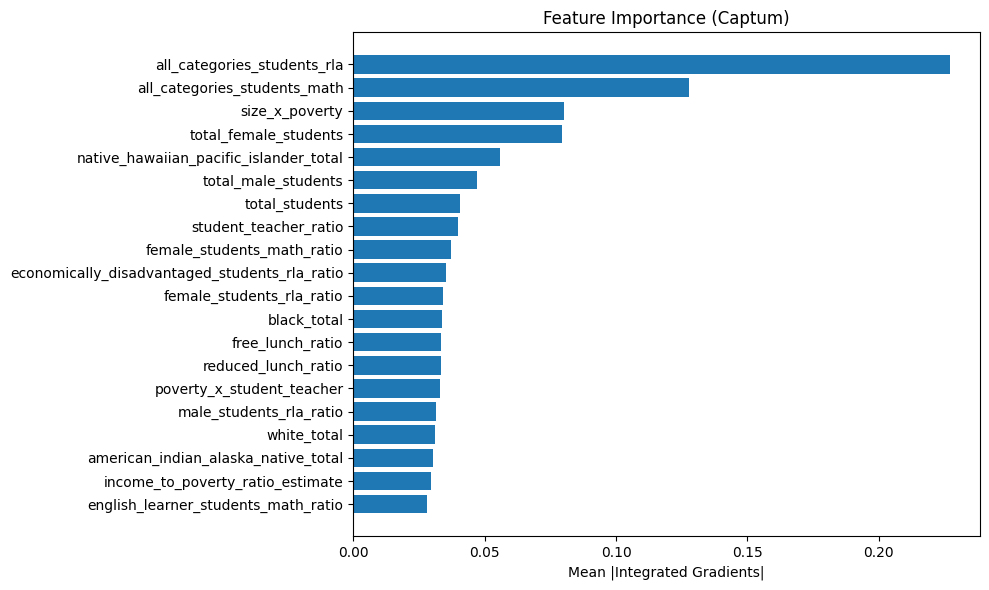

In [ ]:
checkpoint = torch.load("best_model.pth", map_location="cpu")

model1 = TabularModel(cat_dims, len(feature_cols) - len(cat_cols), out_dims=1)
model1.load_state_dict(checkpoint["model_state_dict"])
model1.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1.to(device)

X_cat = X_test_cat[:200].to(device)
X_num = X_test_num[:200].to(device)

feature_names = feature_cols[len(cat_cols):]

def forward_func(num_x, cat_x):
    return model1(cat_x, num_x).squeeze()

ig = IntegratedGradients(forward_func)

attr = ig.attribute(
    inputs=X_num,
    additional_forward_args=(X_cat,),
    n_steps=50
)

attr = attr.detach().cpu().numpy()
importance = np.mean(np.abs(attr), axis=0)

idx = np.argsort(importance)[::-1]

sorted_names = [feature_names[i] for i in idx]
sorted_vals = importance[idx]

print("\nTop Feature Importance (Captum IG):")
for n, v in list(zip(sorted_names, sorted_vals))[:20]:
    print(f"{n:40s} {v:.6f}")

plt.figure(figsize=(10, 6))
plt.barh(sorted_names[:20][::-1], sorted_vals[:20][::-1])
plt.xlabel("Mean |Integrated Gradients|")
plt.title("Feature Importance (Captum)")
plt.tight_layout()
plt.show()

In [ ]:
def evaluate(loader):
    preds = []
    targets = []

    with torch.no_grad():
        for x_cat, x_num, y in loader:
            out = model1(x_cat, x_num)

            preds.append(out)
            targets.append(y)

    preds = torch.cat(preds)
    targets = torch.cat(targets)

    return preds, targets


train_preds, train_targets = evaluate(train_loader)
test_preds, test_targets   = evaluate(test_loader)
val_preds, val_targets = evaluate(val_loader)

train_preds = train_preds * y_std + y_mean
test_preds  = test_preds  * y_std + y_mean
val_preds  = val_preds    * y_std + y_mean

train_targets = train_targets * y_std + y_mean
test_targets  = test_targets  * y_std + y_mean
val_targets  = val_targets    * y_std + y_mean

train_preds = train_preds.numpy()
test_preds  = test_preds.numpy()
val_preds  = val_preds.numpy()

train_targets = train_targets.numpy()
test_targets  = test_targets.numpy()
val_targets  = val_targets.numpy()

r2_train = r2_score(train_targets, train_preds)
r2_test  = r2_score(test_targets, test_preds)
r2_val  = r2_score(val_targets, val_preds)

test_rmse = mean_squared_error(test_targets, test_preds)
test_mae  = mean_absolute_error(test_targets, test_preds)
val_rmse = mean_squared_error(val_targets, val_preds)
val_mae  = mean_absolute_error(val_targets, val_preds)

print(f"Train R^2:\t{r2_train:.4f}")
print(f"Test  R^2:\t{r2_test:.4f}")
print(f"Val   R^2:\t{r2_val:.4f}")
print()
print(f"Test RMSE:\t{test_rmse:.4f}")
print(f"Test MAE:\t{test_mae:.4f}")
print()
print(f"Val RMSE:\t{val_rmse:.4f}")
print(f"Val MAE:\t{val_mae:.4f}")

Train R^2:	0.9053
Test  R^2:	0.8533
Val   R^2:	0.8463

Test RMSE:	597.4497
Test MAE:	16.2054

Val RMSE:	591.0461
Val MAE:	16.0881


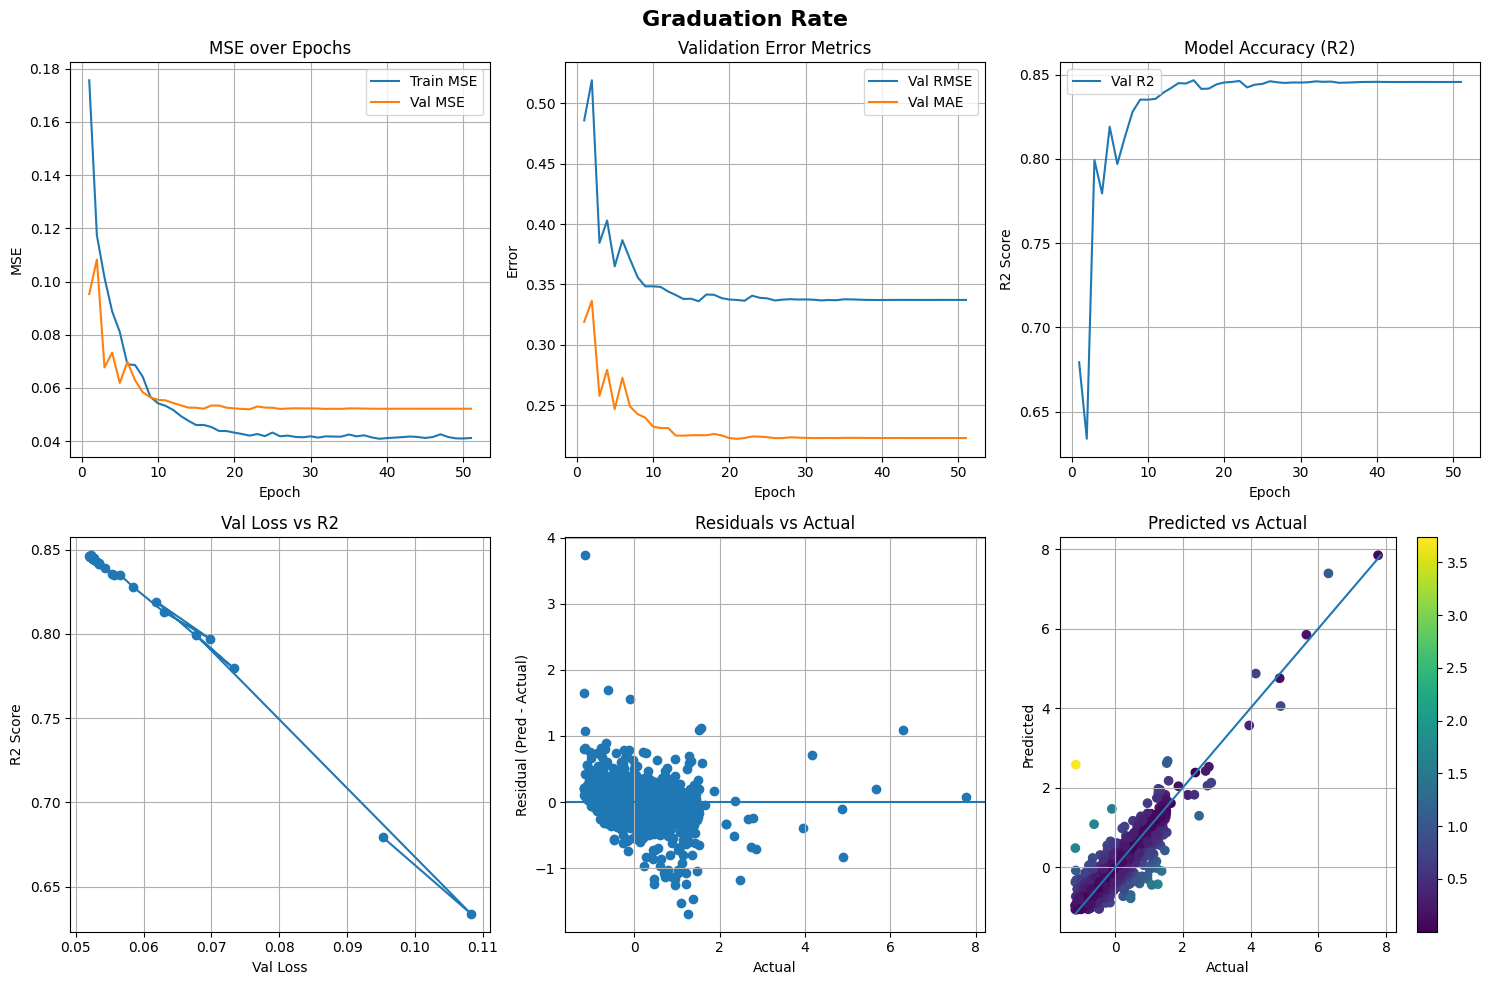

In [ ]:
epochs = range(1, len(train_losses) + 1)

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Graduation Rate', fontsize=16, fontweight='bold')

axs[0, 0].plot(epochs, train_losses, label='Train MSE')
axs[0, 0].plot(epochs, val_losses, label='Val MSE')
axs[0, 0].set_title('MSE over Epochs')
axs[0, 0].set_xlabel('Epoch')
axs[0, 0].set_ylabel('MSE')
axs[0, 0].legend()
axs[0, 0].grid()

axs[0, 1].plot(epochs, val_rmse_list, label='Val RMSE')
axs[0, 1].plot(epochs, val_mae_list, label='Val MAE')
axs[0, 1].set_title('Validation Error Metrics')
axs[0, 1].set_xlabel('Epoch')
axs[0, 1].set_ylabel('Error')
axs[0, 1].legend()
axs[0, 1].grid()

axs[0, 2].plot(epochs, val_r2, label='Val R2')
axs[0, 2].set_title('Model Accuracy (R2)')
axs[0, 2].set_xlabel('Epoch')
axs[0, 2].set_ylabel('R2 Score')
axs[0, 2].legend()
axs[0, 2].grid()

axs[1, 0].plot(val_losses, val_r2, marker='o')
axs[1, 0].set_title('Val Loss vs R2')
axs[1, 0].set_xlabel('Val Loss')
axs[1, 0].set_ylabel('R2 Score')
axs[1, 0].grid()

model.eval()
preds_all = []
y_all = []

with torch.no_grad():
    for x_cat, x_num, y in val_loader:
        preds = model(x_cat, x_num).squeeze()
        preds_all.append(preds)
        y_all.append(y)

preds_all = torch.cat(preds_all).cpu().numpy()
y_all = torch.cat(y_all).cpu().numpy()

residuals = preds_all - y_all

axs[1, 1].scatter(y_all, residuals)
axs[1, 1].axhline(0)
axs[1, 1].set_title('Residuals vs Actual')
axs[1, 1].set_xlabel('Actual')
axs[1, 1].set_ylabel('Residual (Pred - Actual)')
axs[1, 1].grid()

errors = abs(preds_all - y_all)

sc = axs[1, 2].scatter(y_all, preds_all, c=errors)

min_val = min(y_all.min(), preds_all.min())
max_val = max(y_all.max(), preds_all.max())
axs[1, 2].plot([min_val, max_val], [min_val, max_val])

axs[1, 2].set_title('Predicted vs Actual')
axs[1, 2].set_xlabel('Actual')
axs[1, 2].set_ylabel('Predicted')
axs[1, 2].grid()

fig.colorbar(sc, ax=axs[1, 2])

plt.tight_layout()
plt.show()